<a href="https://colab.research.google.com/github/DhanushV2006/AIML/blob/main/Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
import matplotlib.pyplot as plt

x, y = load_breast_cancer(return_X_y=True)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

base_model = DecisionTreeClassifier(max_depth=1, random_state=42 )
boost_model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators= 50,
    learning_rate = 1.0,
    random_state= 42A
)

boost_model.fit(x_train, y_train)

y_pred = boost_model.predict(x_test)
y_prob = boost_model.predict_proba(x_test)[:, 1]

print("adaBoost Evaluation")
print("Accuracy:", accuracy_score (y_test, y_pred) )
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("Confusion Matrix: \n") , (confusion_matrix(y_test, y_pred))
print("Classification Report: \n") , (classification_report(y_test, y_pred))




adaBoost Evaluation
Accuracy: 0.9649122807017544
Precision: 0.958904109589041
Recall: 0.9859154929577465
F1 Score: 0.9722222222222222
Confusion Matrix: 

Classification Report: 



(None,
 '              precision    recall  f1-score   support\n\n           0       0.98      0.93      0.95        43\n           1       0.96      0.99      0.97        71\n\n    accuracy                           0.96       114\n   macro avg       0.97      0.96      0.96       114\nweighted avg       0.97      0.96      0.96       114\n')

Cross-Validation Scores: [0.95614035 0.95614035 0.99122807 0.96491228 0.97345133]
Mean CV Score: 0.9683744760130415
Single Tree Accuracy: 0.8947368421052632
AdaBoost Accuracy  0.9649122807017544


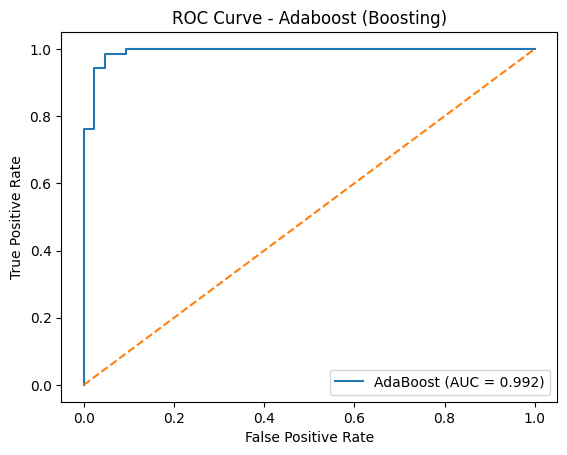

In [5]:
cv_scores = cross_val_score(boost_model, x, y, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

single_model = DecisionTreeClassifier(max_depth=1, random_state=42)
single_model.fit(x_train, y_train)
single_pred = single_model.predict(x_test)

print("Single Tree Accuracy:", accuracy_score(y_test, single_pred))
print("AdaBoost Accuracy ", accuracy_score(y_test, y_pred))

# Make sure to import roc_curve from sklearn.metrics
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AdaBoost (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Adaboost (Boosting)")
plt.legend()
plt.show()